## Topic: Sequential LLM Workflow 

- LLM Workflow:  
    - START ---> LLM ---> END

- Where, 
    - LLM : ollama

In [3]:
# import necessary libraries
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict
from dotenv import load_dotenv

c:\Users\kz\anaconda3\envs\GenAI\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


### Define LLM

In [5]:
model = ChatOllama(
    model="llama3.2:latest",
    temperature=0
)

### step 1 : Define a state

In [4]:
# 1. Define the State

class LLMState(TypedDict):
    question: str
    answer : str


### Step 3: Define Node

In [6]:
def llm_QN(state:LLMState) -> LLMState:

    # Step1: extract the state information
    question = state["question"]

    # Step2: Perform the calculation (here, call the LLM)
    # define a prompt
    prompt = f"Answer the following question {question}"

    # ask the question to the LLM
    answer = model.invoke(prompt).content

    # Step 3: Partial update the state values
    state["answer"] = answer

    # Step 4: return the  partial updated state value
    return state



### step 2 : Define Graph

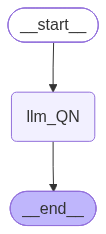

In [7]:
# create an object of StateGraph
graph = StateGraph(LLMState)

# add nodes
graph.add_node("llm_QN", llm_QN)

# add edges
graph.add_edge(START, "llm_QN")
graph.add_edge("llm_QN", END)

# compile
graph.compile()

In [8]:
# compile
workflow = graph.compile()

# Execute
initial_state = {
    "question": "who is the father of computer science?"
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'who is the father of computer science?', 'answer': "The father of computer science is often considered to be Alan Turing (1912-1954), a British mathematician, computer scientist, logician, philosopher, and cryptographer. Turing is widely regarded as one of the most influential figures in the development of computer science, and his work laid the foundation for the field.\n\nTuring's contributions to computer science include:\n\n1. The Turing Machine: a theoretical model for a computer that is still studied today.\n2. The Automatic Computing Engine (ACE): a proposed computer design that was never built, but influenced the development of modern computers.\n3. Codebreaking: Turing worked at the Government Code and Cypher School (GC&CS) at Bletchley Park, where he played a crucial role in cracking the German Enigma code during World War II.\n4. The Turing Test: a measure of a machine's ability to exhibit intelligent behavior equivalent to, or indistinguishable from, that of a

In [9]:
# see the only answer part
print(final_state["answer"])

The father of computer science is often considered to be Alan Turing (1912-1954), a British mathematician, computer scientist, logician, philosopher, and cryptographer. Turing is widely regarded as one of the most influential figures in the development of computer science, and his work laid the foundation for the field.

Turing's contributions to computer science include:

1. The Turing Machine: a theoretical model for a computer that is still studied today.
2. The Automatic Computing Engine (ACE): a proposed computer design that was never built, but influenced the development of modern computers.
3. Codebreaking: Turing worked at the Government Code and Cypher School (GC&CS) at Bletchley Park, where he played a crucial role in cracking the German Enigma code during World War II.
4. The Turing Test: a measure of a machine's ability to exhibit intelligent behavior equivalent to, or indistinguishable from, that of a human.

Turing's work on computer science, artificial intelligence, and 